<a href="https://colab.research.google.com/github/cchan555/lis4693/blob/main/lab-5/ChanLab5Mar252026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lab 5: Topic Modeling
Cody Chan

In [ ]:
#
# Setup for Lab 5
#

# Installing and import
!pip install gensim
!pip install pyldavis
!pip install nltk

# Downloard NLTK stopword list (common words)
import nltk
nltk.download('stopwords')

# Ignore warnings
import warnings
warnings.filterwarnings('ignore', category=DeprecationWarning)

import pandas as pd # Manipulation library
from nltk.corpus import stopwords # NLTK's english stopword list
import string
import gensim.corpora as corpora # gensim tools
from gensim.models import LdaModel

import pyLDAvis.gensim_models
pyLDAvis.enable_notebook()

import requests
import io


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

## Task 1

In [ ]:
# Task 1
# On Lens website, export bibliographic medadata for atleast 1000 articles

url ="https://raw.githubusercontent.com/cchan555/lis4693/refs/heads/main/lab-5/lens-export-electric-vehicles.csv"
response = requests.get(url)
response.raise_for_status()
text = response.text
df = pd.read_csv(io.StringIO(text))
print(df.head())

docs = df.Abstract.tolist()
print(docs[0])


               Lens ID                                              Title  \
0  000-050-681-184-461  b'Integrated Vehicle Thermal Management - Comb...   
1  000-072-636-955-893                Advanced Technology Vehicle Testing   
2  000-567-389-723-079  A STUDY ON ENERGY MANAGEMENT CONTROL STRATEGY ...   
3  000-569-437-047-781  Study on the Promotion and Operation Mode of H...   
4  000-597-261-925-971    Research on the Electric Vehicle Control System   

  Date Published  Publication Year                Publication Type  \
0            NaN            2013.0                             NaN   
1     2003-11-01            2003.0                             NaN   
2     2016-03-03            2016.0  conference proceedings article   
3            NaN            2014.0                 journal article   
4     2015-08-31            2015.0                 journal article   

                                        Source Title     ISSNs  \
0                                                N

### Task 1: Explanation of dataset
This dataset contains at least 1000 articles on the topic of electric vehicles, exported from Lens.org in CSV format. The search query I used was "electric vehicles". I chose this dataset because electric vehicles have been increasing exponentially over the years. Companies have been implementing technologies to transition from the tradational gas powered car to hybrid, as well as electric vehicles. This topic also spans into my field as a Computer engineer, as it relates to electronics and battery technology.

## Task 2

In [ ]:
# Task 2: Display the first 10 fows of the dataset and select the column for topic modeling
df.head(10)

# Select columns for topic modeling
# Note: the dataset has a lot of "NaN".
# Cleanig up the dataset before proceeding is nessessary

# Drop rows where Abstract is missing (NaN) so LDA does not crash
df = df[["Title", "Abstract"]].dropna(subset=["Abstract"]).reset_index(drop=True)
docs = df.Abstract.tolist()
print(f"Total documents for modeling: {len(docs)}")
print(docs[0])


Total documents for modeling: 892
Plug-in hybrid electric vehicles and electric vehicles have increased vehicle thermal management complexity, using separate coolant loop for advanced power electronics and electric motors. Additional thermal components result in higher costs. Multiple cooling loops lead to reduced range due to increased weight. Energy is required to meet thermal requirements. This presentation for the 2013 Annual Merit Review discusses integrated vehicle thermal management by combining fluid loops in electric drive vehicles.


### Task 2: Provide rationale for selecting that particular column for topic modeling
When considering a column for topic modeling, it is best to have more data, a larger corpus, in the column. More data does not mean more words, but it has to be good quality and relevant words. In this case, the Abstract column has the most words and good quality words for each article. The abstract summarizes the problem, method, and gives a general summary of its findings, which is a great column for topic modeling. If we look at other columns like Title or Publisher, they are too short or will not give a good representation of the full context. The Abstract column has lots of variety in words, which allows the model to see different subtopics.

## Task 3

In [ ]:
# Task 3
# Preprocess text data for topic modeling and create bag of words corpus

stop_words = stopwords.words('english')
def clean_doc(doc):
    no_punct = ''
    for c in doc:
        if c not in string.punctuation:
            no_punct = no_punct+c
    # with list comprehension
    # no_punct = ''.join([c for c in doc if c not in string.punctuation])

    words = no_punct.lower().split()

    #final_words = []
    #for word in words:
        #if word not in stop_words:
           # final_words.append(word)

    # with list comprehension
    final_words = [ # Use this to ensure no numbers occur
        word for word in words
        if word not in stop_words and not word.isdigit()
    ]

    return final_words

In [ ]:
# Adding custom stopwords
custom_stopwords = ['using', 'result', 'method', 'review', "lead", "due",
                    "required", "annual", "loop", "additional", "meet", "merit",
                    "higher", "presentation", "discusses", "multiple"]
stop_words.extend(custom_stopwords)
print(f"New stopwords added: {custom_stopwords}")

# Apply cleaning function to list
cleaned_docs = [clean_doc(doc) for doc in docs]
print(cleaned_docs[0])
id2word = corpora.Dictionary(cleaned_docs)
corpus = [id2word.doc2bow(cleaned_doc) for cleaned_doc in cleaned_docs]
print("Cleaning process, ID-Word Index, and Corpus have been regenerated with new stopwords.")


New stopwords added: ['using', 'result', 'method', 'review', 'lead', 'due', 'required', 'annual', 'loop', 'additional', 'meet', 'merit', 'higher', 'presentation', 'discusses', 'multiple']
['plugin', 'hybrid', 'electric', 'vehicles', 'electric', 'vehicles', 'increased', 'vehicle', 'thermal', 'management', 'complexity', 'separate', 'coolant', 'advanced', 'power', 'electronics', 'electric', 'motors', 'thermal', 'components', 'costs', 'cooling', 'loops', 'reduced', 'range', 'increased', 'weight', 'energy', 'thermal', 'requirements', 'integrated', 'vehicle', 'thermal', 'management', 'combining', 'fluid', 'loops', 'electric', 'drive', 'vehicles']
Cleaning process, ID-Word Index, and Corpus have been regenerated with new stopwords.


In [ ]:
# Create LDA with 10 topics and print

lda_10 = LdaModel(corpus=corpus, id2word=id2word, num_topics=10)

print("\nTop 5 words per topic (LDA: 10 Topics):\n")
for topic_id in range(10):
    topic_terms = lda_10.show_topic(topic_id, topn=5)

    print(f"Topic {topic_id}:")

    for word, prob in topic_terms:
        print(f"{word} ({prob:.4f})")
    print()


Top 5 words per topic (LDA: 10 Topics):

Topic 0:
electric (0.0788)
vehicle (0.0466)
vehicles (0.0362)
hybrid (0.0118)
battery (0.0080)

Topic 1:
electric (0.0303)
charging (0.0299)
vehicle (0.0174)
vehicles (0.0144)
load (0.0105)

Topic 2:
electric (0.0372)
vehicles (0.0338)
vehicle (0.0195)
charging (0.0086)
based (0.0053)

Topic 3:
vehicles (0.0393)
electric (0.0330)
vehicle (0.0095)
model (0.0087)
battery (0.0084)

Topic 4:
electric (0.0592)
vehicles (0.0552)
vehicle (0.0189)
energy (0.0113)
battery (0.0092)

Topic 5:
electric (0.0419)
vehicle (0.0406)
vehicles (0.0204)
hybrid (0.0098)
charging (0.0077)

Topic 6:
electric (0.0708)
vehicles (0.0440)
vehicle (0.0335)
charging (0.0126)
energy (0.0109)

Topic 7:
electric (0.0539)
vehicle (0.0404)
vehicles (0.0229)
energy (0.0112)
charging (0.0079)

Topic 8:
electric (0.0466)
charging (0.0339)
vehicles (0.0325)
vehicle (0.0134)
power (0.0093)

Topic 9:
electric (0.0582)
vehicles (0.0470)
vehicle (0.0304)
power (0.0089)
energy (0.0085)


In [ ]:
# Finding stopwords to take out
#cleaned_with_custom_stopwords = clean_doc(docs[0])
#print("\nOriginal document (first one):")
#print(docs[0])
#print("\nCleaned document with custom stopwords:")
#print(cleaned_with_custom_stopwords)

In [ ]:
# Create LDA with 20 topics and print

lda_20 = LdaModel(corpus=corpus, id2word=id2word, num_topics=20)

print("\nTop 5 words per topic (LDA: 20 Topics):\n")
for topic_id in range(20):
    topic_terms = lda_20.show_topic(topic_id, topn=5)

    print(f"Topic {topic_id}:")

    for word, prob in topic_terms:
        print(f"{word} ({prob:.4f})")
    print()


Top 5 words per topic (LDA: 20 Topics):

Topic 0:
vehicles (0.0621)
electric (0.0612)
vehicle (0.0143)
charging (0.0135)
power (0.0053)

Topic 1:
vehicles (0.0383)
electric (0.0374)
vehicle (0.0176)
battery (0.0111)
testing (0.0085)

Topic 2:
electric (0.0318)
vehicles (0.0230)
vehicle (0.0166)
power (0.0088)
batteries (0.0072)

Topic 3:
electric (0.0518)
vehicles (0.0227)
vehicle (0.0205)
energy (0.0102)
charging (0.0101)

Topic 4:
electric (0.0551)
vehicle (0.0527)
vehicles (0.0298)
charging (0.0173)
hybrid (0.0125)

Topic 5:
electric (0.0395)
vehicle (0.0284)
vehicles (0.0192)
power (0.0103)
charging (0.0097)

Topic 6:
electric (0.0319)
vehicles (0.0222)
vehicle (0.0124)
charging (0.0096)
energy (0.0090)

Topic 7:
vehicles (0.0099)
electric (0.0090)
battery (0.0082)
vehicle (0.0064)
energy (0.0049)

Topic 8:
electric (0.0478)
vehicle (0.0298)
vehicles (0.0212)
energy (0.0167)
power (0.0081)

Topic 9:
vehicles (0.0123)
electric (0.0118)
control (0.0082)
vehicle (0.0080)
charging (0.

### Task 3: Comparison and Justification
When examining the LDA model for 10 topics and 20 topics, they are both remarkably similar. Both topics have words that many labels have in common. The main distinction between the two LDA models is that for topic 10, it gives fewer topics, making the labels feel more specific. While for the LDA model with 20 topics, there are more labels, which introduce more labels with similar themes. This is due to the model trying to split into 20 labels, which causes repetition. For example, in the LDA model for 20 topics, topics 1, 6, and 14 have the same labels, so it is harder to make it unique. <br>

When choosing a model that is better for interpretation, LDA 10 topics is the best option. For quality, high quality can mean words that have a clear relation to each other but still have meaningful labels. For low quality, lots of overlap with other labels. In this case, LDA 10 topics have fewer topics and less overlap, making it easier to interpret. For LDA 20 topics, a lot of repeating labels, making it harder to find a good pattern or to interpret. For LDA 20 topics, the model tries to split the labels into too many sections, so it is hard for someone to analyze at a glance.

## Task 4: Visualize topic results using bar graph for topic is 5, 10, 15, 20.

In [ ]:
# Task 4
# Visualize topics

topic_data = []

# Topics 5, 10, 15, 20
target_topic_ids = [4, 9, 14, 19] # index 19 represents 20th topic (Index start 0)

# Label to each topic number
topic_labels = {
    4: "5: Hybrid Electric Vehicles",
    9: "10: Battery and Energy Systems",
    14: "15: Electric Vehicle Power and Energy",
    19: "20: Electric Vehicle Battery"
}

for topic_id in target_topic_ids:
    # Retrieve the top 10 words and their probabilities for the current topic
    topic_terms = lda_20.show_topic(topic_id, topn=10)

    for word, prob in topic_terms:
        topic_data.append({
            'Topic ID': topic_id,
            'Word': word,
            'Probability': prob
        })

# Build dataframe
df_topic_words = pd.DataFrame(topic_data)
# Create Unique Labels for bar plots
df_topic_words['Topic Label'] = df_topic_words['Topic ID'].map(topic_labels)
print("DataFrame 'df_topic_words' created successfully with topic words and probabilities.")
print(df_topic_words.head(12))



DataFrame 'df_topic_words' created successfully with topic words and probabilities.
    Topic ID      Word  Probability                     Topic Label
0          4  electric     0.055143     5: Hybrid Electric Vehicles
1          4   vehicle     0.052676     5: Hybrid Electric Vehicles
2          4  vehicles     0.029777     5: Hybrid Electric Vehicles
3          4  charging     0.017338     5: Hybrid Electric Vehicles
4          4    hybrid     0.012512     5: Hybrid Electric Vehicles
5          4   battery     0.012016     5: Hybrid Electric Vehicles
6          4    system     0.010259     5: Hybrid Electric Vehicles
7          4     power     0.006934     5: Hybrid Electric Vehicles
8          4     paper     0.006874     5: Hybrid Electric Vehicles
9          4    energy     0.006790     5: Hybrid Electric Vehicles
10         9  vehicles     0.012345  10: Battery and Energy Systems
11         9  electric     0.011755  10: Battery and Energy Systems


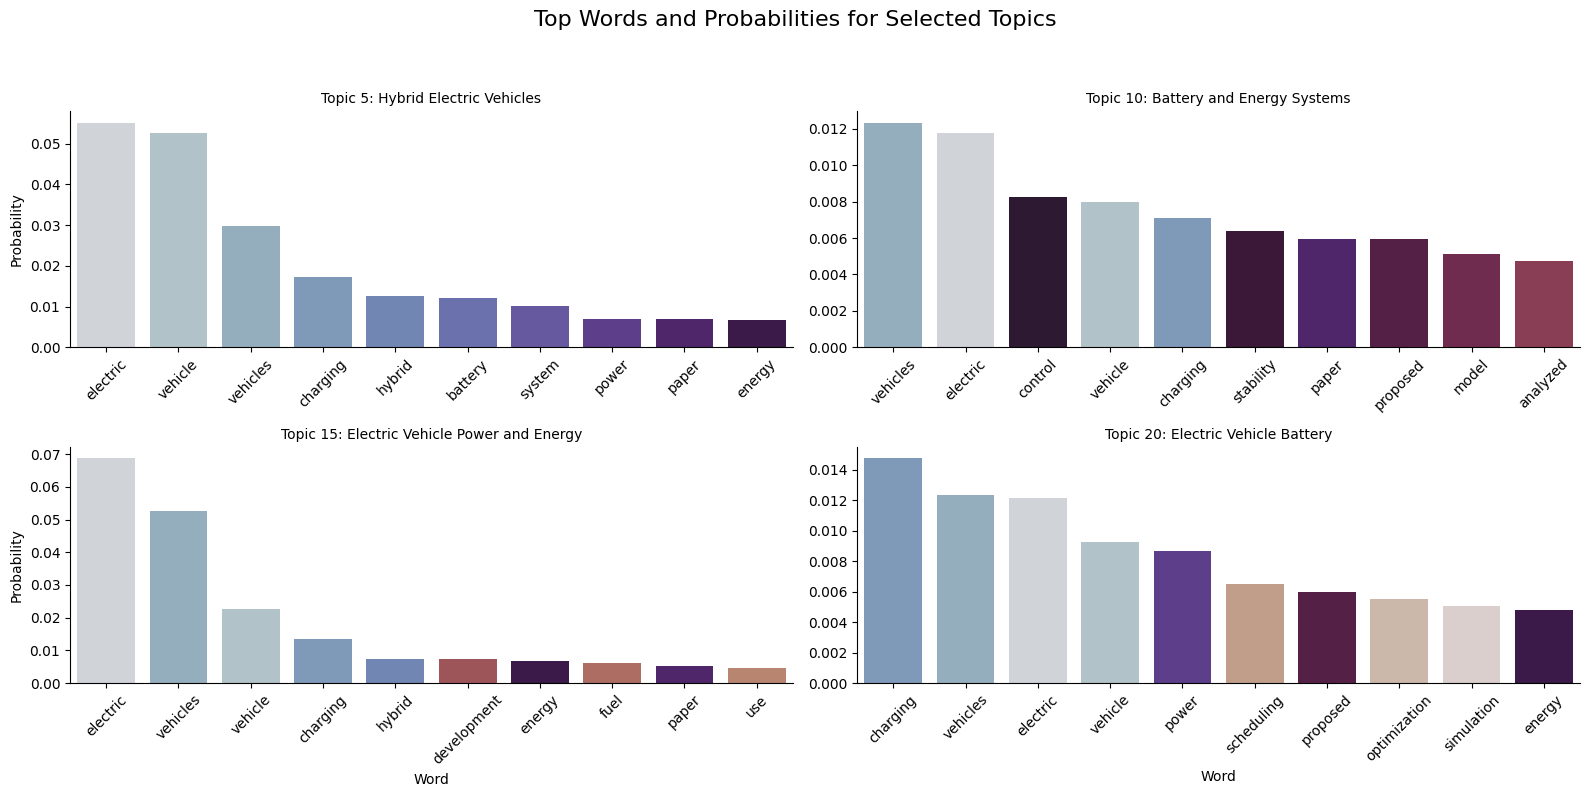

In [ ]:
# Create Bar chart

import matplotlib.pyplot as plt
import seaborn as sns

# Create the facet bar plot
g = sns.catplot(data=df_topic_words, x='Word', y='Probability', col='Topic Label', col_wrap=2, kind='bar',
                height=4, aspect=2, hue='Word', legend=False, palette='twilight', sharex=False, sharey=False)

# Customize the plot
g.set_axis_labels("Word", "Probability")
g.set_titles("Topic {col_name}")

# Rotate x-axis labels for better readability
for ax in g.axes.flat:
    for label in ax.get_xticklabels():
        label.set_rotation(45)
    ax.tick_params(axis='x', labelbottom=True)

plt.suptitle('Top Words and Probabilities for Selected Topics', y=1.02, fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.98])
plt.show()

In [ ]:
# Interactive Visualization
vis = pyLDAvis.gensim_models.prepare(lda_20, corpus, id2word, mds="mmds", R=30)
vis

PreparedData(topic_coordinates=              x         y  topics  cluster       Freq
topic                                                
18    -0.085455  0.019701       1        1  29.610970
10    -0.059418  0.030739       2        1  16.830759
4     -0.088762 -0.014012       3        1  13.503561
14    -0.096425  0.036327       4        1   8.281576
15    -0.057780  0.090924       5        1   6.110573
13    -0.051884 -0.024689       6        1   5.921841
0     -0.079778  0.071553       7        1   3.526375
11    -0.069881 -0.045791       8        1   2.905532
17    -0.031905 -0.089256       9        1   2.182842
8     -0.005639 -0.077670      10        1   2.093708
6      0.030550 -0.054095      11        1   1.839126
16     0.006885  0.083680      12        1   1.523365
19     0.050042 -0.128460      13        1   1.438048
1      0.055627  0.085052      14        1   1.255354
3     -0.006508  0.027036      15        1   0.983696
5      0.029574  0.033502      16        1   0.706719
2      0.077821  0.011843      17        1   0.448765
9      0.102230 -0.067755      18        1   0.433476
7      0.131480 -0.020962      19        1   0.227682
12     0.149228  0.032334      20        1   0.176032, topic_info=             Term         Freq        Total Category  logprob  loglift
8        electric  5470.000000  5470.000000  Default  30.0000  30.0000
26       vehicles  3326.000000  3326.000000  Default  29.0000  29.0000
25        vehicle  2910.000000  2910.000000  Default  28.0000  28.0000
225      charging   874.000000   874.000000  Default  27.0000  27.0000
10         energy   704.000000   704.000000  Default  26.0000  26.0000
..            ...          ...          ...      ...      ...      ...
332   environment     0.233663   107.140260  Topic20  -6.4517   0.2142
508      learning     0.201437    25.088344  Topic20  -6.6002   1.5176
608  conventional     0.229309   154.041967  Topic20  -6.4706  -0.1677
314          used     0.235704   257.521156  Topic20  -6.4430  -0.6540
492          data     0.213367   194.051321  Topic20  -6.5426  -0.4706

[1530 rows x 6 columns], token_table=      Topic      Freq        Term
term                             
2933      1  0.238677      1000kg
2933      7  0.238677      1000kg
2933     14  0.238677      1000kg
382       1  0.782830      10kwkg
383       1  0.780624        19wh
...     ...       ...         ...
4095      2  0.729553   yawmoment
5924      9  0.681322    yearsand
5965      1  0.737406    yinchuan
5966      1  0.736210  yinchuan’s
7025      8  0.703554      ‐based

[4026 rows x 3 columns], R=30, lambda_step=0.01, plot_opts={'xlab': 'PC1', 'ylab': 'PC2'}, topic_order=[19, 11, 5, 15, 16, 14, 1, 12, 18, 9, 7, 17, 20, 2, 4, 6, 3, 10, 8, 13])

### Task 4: Based on results -

#### Labeling done in code above ^

#### Which topic appears most distinct?

The most distinct topics would be topic 5 and topic 20. Both of these topics have various types of keywords that make them stand out compared to the others. For topic 5, it has energy, power, hybrid, and charging, which focuses on charging infructure and consumption. For topic 20, it has system, model, battery, charging, which emophasize integrated vehicles.

#### Which topic overlaps substantially?

Between then 4 topics analyzed, topics 5, 10, and 15 have the most overlap like charging, power, hybrid, and energy. The common ground mainly occurs between two topics and not entirely between the three chosen. This still indicates overlapping, which all relate to EV systems and management.

#### Do the top keywords align with your expectations from the dataset?

When analyzing the top keywords, they do align with my expectations from the dataset. The custom stopword was able to remove all of the tradiaitonal filler words to allow the technical terms to stand out. The main topics of these articles include EV systems, energy, charging, and system integration.



## Task 5: Brief Reflection

#### What went well? What did not or what challenges you encountered?

During the LDA model process, reproducing the topics went smoothly. Adding in custom stopwords made a noticeable difference when running the LDA model. I was able to iterate through to find what words I needed to take out. However, a challenge I encountered was iterating on the stopwords. After running the LDA model, it was time-consuming. After running the LDA model without stopwords, it took my computer a long time to load in  the output, and then I would have to scroll up and down to see what stopwords I needed to add. There was a time when the clean function did not fully remove all of the numbers, so I had to modify some previous code to fix the issue. I did not have any issues with the funcion getting rid of common stopword. Another challenge I encountered was choosing between the LDA model 10 topic and the LDA model 20 topic. Initially, they were both very similar, and it was hard to distinguish what was different. A last challenge I encountered was the overall loading/compiling of Google Colab. It often took a long time to load the output, and sometimes it would not load at all and be stuck on the loading phase. I often had to refresh the page or wait a few hours before I continued working.

#### In what way could topic modeling be integrated into your current or future professional or research work?

Topic modeling can be used in a literature review in engineering or data analytics. Topic modeling is good for analyzing a large corpus of papers to find a common theme between the papers instead of reading them individually. For example, in one of my classes, I am creating a proposal to quantify a type of restoration filter for license plate recognition under synthetic blur degradation, and I needed to go through and find papers on common issues. There were not many research papers where the whole experiment was purely under a controlled setting, so I had to read lots of papers related to vehicle licence plates. I was researching Automatic License Plate Recognition (ALPR), which is a system where camera use to detect and record vehicle license plates. Rather than going through each research paper or article, I could use topic modeling to look through which paper correlates to what I am looking for, saving lots of time.